In [ ]:
import pandas as pd

# 1. Load the dataset
# We use encoding='latin1' because these Excel-based CSVs often have special characters
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# 2. Look at the first 5 rows
print("--- Data Preview ---")
display(df.head())

# 3. Check what columns we have and if there are empty cells
print("\n--- Data Information ---")
df.info()


--- Data Preview ---


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-nu

In [ ]:
# 1. Convert 'Order Date' from text to a real Date format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 2. Create new columns for 'Month' and 'Year' to help with trends later
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

# 3. Double check for any empty (Null) values just in case
print("Missing values in each column:")
print(df.isnull().sum())

# 4. See the changes
print("\n--- Updated Data Preview ---")
display(df[['Order Date', 'Year', 'Month', 'Sales']].head())


Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
dtype: int64

--- Updated Data Preview ---


,Order Date,Year,Month,Sales
0,2016-11-08,2016,November,261.9600
1,2016-11-08,2016,November,731.9400
2,2016-06-12,2016,June,14.6200
3,2015-10-11,2015,October,957.5775
4,2015-10-11,2015,October,22.3680


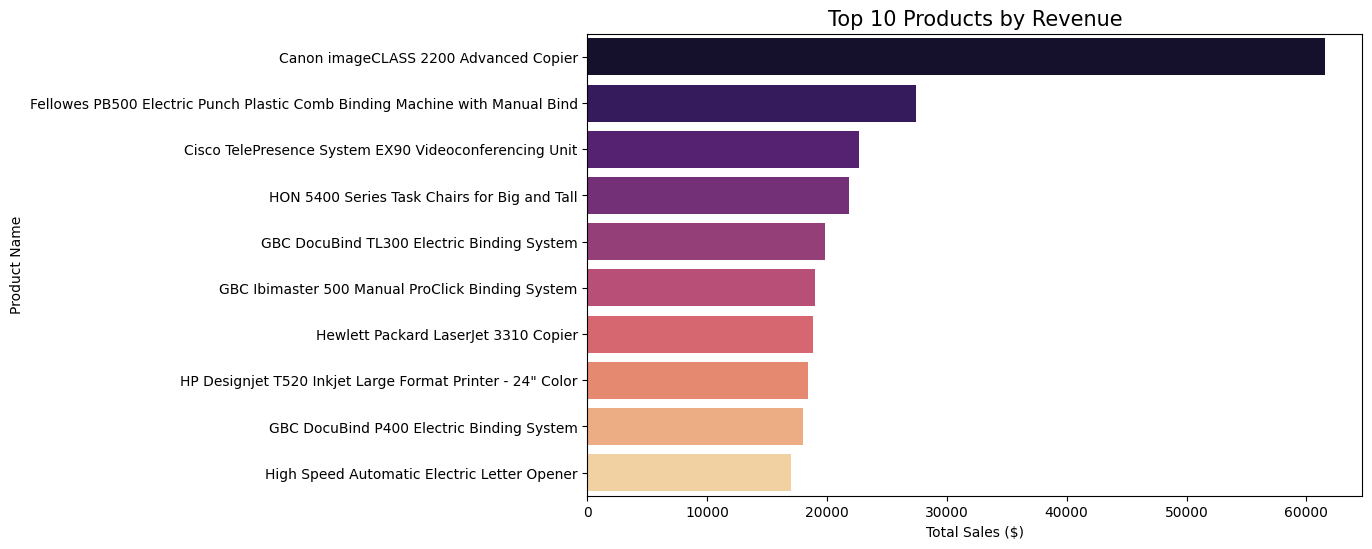

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by Product Name and sum the Sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

# 2. Create a Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette='magma',
    legend=False
)

# 3. Add labels
plt.title('Top 10 Products by Revenue', fontsize=15)
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.show()


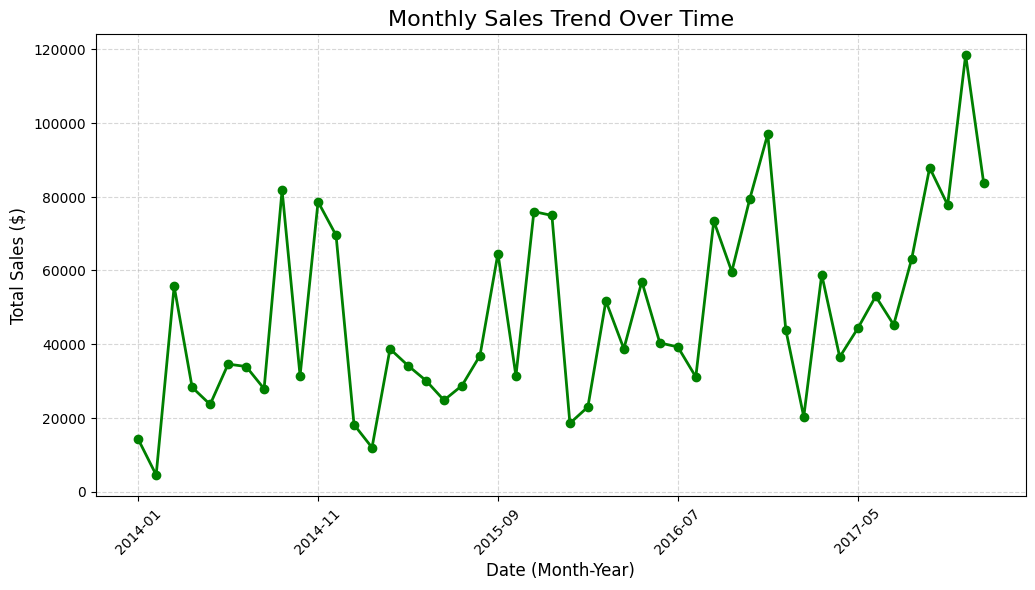

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a simplified 'Month-Year' column for the trend
df['Month_Year'] = df['Order Date'].dt.to_period('M').astype(str)

# 2. Group data by Month_Year and sum the Sales
monthly_trend = df.groupby('Month_Year')['Sales'].sum()

# 3. Create a Line Chart
plt.figure(figsize=(12, 6))
monthly_trend.plot(kind='line', marker='o', color='green', linewidth=2)

# 4. Add Professional Labels
plt.title('Monthly Sales Trend Over Time', fontsize=16)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xlabel('Date (Month-Year)', fontsize=12)
plt.xticks(rotation=45) # Tilts the dates so they don't overlap
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


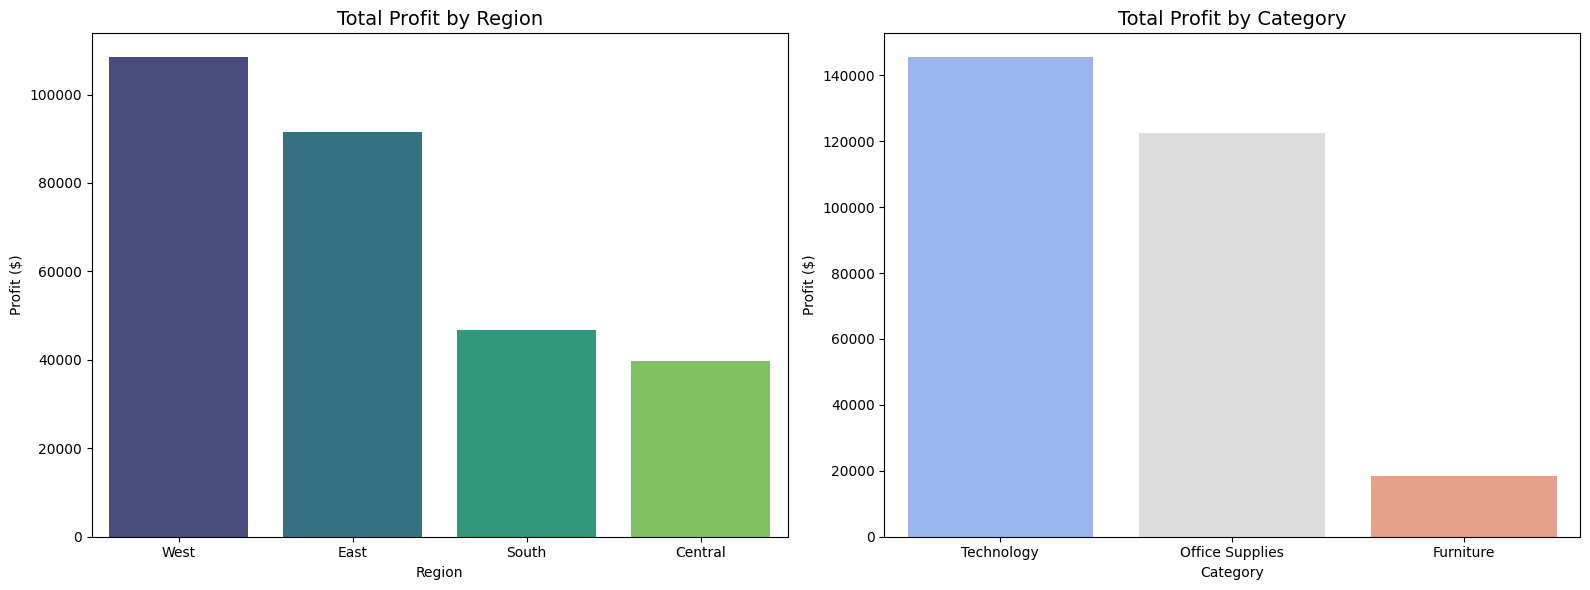

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Grouping data to find Total Profit
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

# 2. Setting up the side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Profit by Region
sns.barplot(x=region_profit.index, y=region_profit.values, ax=ax[0], palette='viridis', hue=region_profit.index, legend=False)
ax[0].set_title('Total Profit by Region', fontsize=14)
ax[0].set_ylabel('Profit ($)')

# Plot B: Profit by Category
sns.barplot(x=category_profit.index, y=category_profit.values, ax=ax[1], palette='coolwarm', hue=category_profit.index, legend=False)
ax[1].set_title('Total Profit by Category', fontsize=14)
ax[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.show()


Strategic Recommendations for Growth:

Focus on West Region: It is our most profitable region. We should increase marketing efforts here.

Promote Technology Products:
 These products have the highest profit margins.

Inventory Management:
 Increase stock levels in October to prepare for the massive sales spike in November and December.


---

